# Mountain–Car Task

In [45]:
import gymnasium as gym
import numpy as np

Observation bounds: [-1.2  -0.07] .. [0.6  0.07]
Number of actions: 3
Actions: 0 = push left, 1 = coast, 2 = push right
  t=0: pos=-0.479, vel=0.000
  t=25: pos=-0.335, vel=0.007
  t=50: pos=-0.334, vel=-0.006
  t=75: pos=-0.478, vel=-0.001


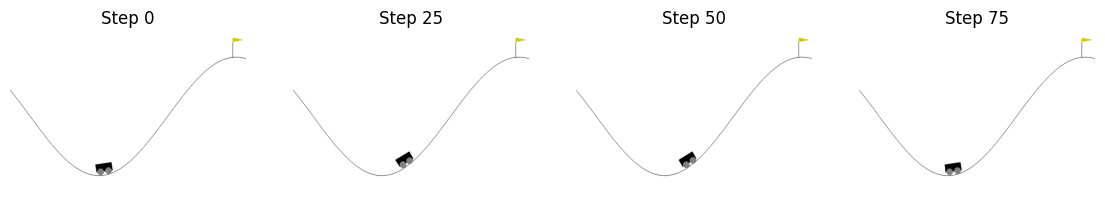

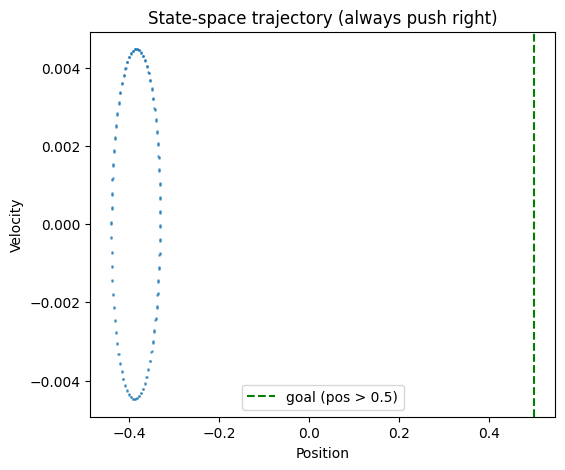

In [46]:
# ============================================================
# 1. Environment setup
# ============================================================
env = gym.make("MountainCar-v0", render_mode="rgb_array")

# Inspect the environment
print(f"Observation bounds: {env.observation_space.low} .. {env.observation_space.high}")
print(f"Number of actions: {env.action_space.n}")
print("Actions: 0 = push left, 1 = coast, 2 = push right")

import matplotlib.pyplot as plt

# --- Always push right: rendered frames + state prints ----------
n_steps = 100
s, _ = env.reset()
frames = []
for t in range(n_steps):
    frames.append(env.render())
    a = 2  # always push right
    s_next, r, terminated, truncated, _ = env.step(a)
    if t % 25 == 0:
        print(f"  t={t}: pos={s[0]:.3f}, vel={s[1]:.3f}")
    if terminated or truncated:
        s, _ = env.reset()
    else:
        s = s_next

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    idx = i * (n_steps // 4)
    ax.imshow(frames[idx])
    ax.set_title(f"Step {idx}")
    ax.axis("off")
plt.show()

# --- State-space trajectory: where does the car go? -------------
states = []
s, _ = env.reset()
for t in range(200):
    states.append(s.copy())
    s_next, r, terminated, truncated, _ = env.step(2)  # always right
    if terminated or truncated:
        break
    s = s_next
states = np.array(states)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(states[:, 0], states[:, 1], ".", markersize=2, alpha=0.5)
ax.axvline(0.5, color="green", linestyle="--", label="goal (pos > 0.5)")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("State-space trajectory (always push right)")
ax.legend()
plt.show()

In [47]:
# ============================================================
# 2. Tile coding — feature construction
# ============================================================
# State is 2D continuous [position, velocity].  Actions are 3 discrete (0,1,2).
# We want a binary feature vector x(s,a) so that Q(s,a,w) = x(s,a) · w
# (linear function approximation).
#
# Tile coding: overlay N offset grids on the state space. Exactly N features
# are active (=1) at any state — one per tiling.  All other features are 0.
#
# Reference bounds:  position ∈ [-1.2, 0.6]
#                   velocity ∈ [-0.07, 0.07]


class TileCoder:
    def __init__(self, n_tilings=8, n_tiles=8, n_actions=3):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.n_actions = n_actions

        # How many features total?  (tiling × tile × tile × action)
        self.total_features = n_tilings * n_tiles * n_tiles * n_actions

        # One small 2D offset per tiling so grids don't align
        self.offsets = [(np.random.uniform(-1 / n_tiles, 1 / n_tiles, 2)) for _ in range(n_tilings)]

    def __call__(self, s, a):
        """Return binary feature vector x(s,a) — exactly n_tilings ones."""
        x = np.zeros(self.total_features)

        # Scale state to [0, n_tiles) in each dimension
        pos = (s[0] + 1.2) / 1.8 * (self.n_tiles - 1)  # <-- scale s[0]    (hint: rescale from [-1.2, 0.6])
        vel = (s[1] + 0.07) / 0.14 * (self.n_tiles - 1)  # <-- scale s[1]    (hint: rescale from [-0.07, 0.07])

        for tiling_idx, (off_pos, off_vel) in enumerate(self.offsets):
            # Which cell does the offset state fall into?
            ti = int(pos + off_pos)  # row (position discretised)
            tj = int(vel + off_vel)  # col (velocity discretised)

            # Compute flat index and set the active feature for action a
            flat_idx = tiling_idx * self.n_tiles * self.n_tiles + ti * self.n_tiles + tj
            x[flat_idx * self.n_actions + a] = 1.0

        return x

In [50]:
# ============================================================
# 3. Linear Sarsa(λ) — training loop
# ============================================================

# --- Setup ---------------------------------------------------
tc = TileCoder(n_tilings=10, n_tiles=9, n_actions=3)
w = np.zeros(tc.total_features)

alpha = 0.1 / tc.n_tilings  # 0.05
gamma = 1.0
lam = 0.5
n_episodes = 9000

steps_per_episode = []

# --- Loop ----------------------------------------------------
for episode in range(n_episodes):
    # Decay ε from 1.0 → 0.02 over first 500 episodes
    eps = max(0.02, 1.0 - episode / 500)

    s, _ = env.reset()

    if np.random.random() < eps:
        a = np.random.randint(3)
    else:
        a = np.argmax([np.dot(tc(s, a_i), w) for a_i in range(3)])

    e = np.zeros_like(w)
    steps = 0
    done = False

    while not done:
        s_next, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if np.random.random() < eps:
            a_next = np.random.randint(3)
        else:
            a_next = np.argmax([np.dot(tc(s_next, a_i), w) for a_i in range(3)])

        # TD error
        q_now = np.dot(tc(s, a), w)
        q_next = 0.0 if done else np.dot(tc(s_next, a_next), w)
        delta = r + gamma * q_next - q_now

        # Accumulating traces
        e = gamma * lam * e + tc(s, a)
        w += alpha * delta * e

        s, a = s_next, a_next
        steps += 1

    steps_per_episode.append(steps)

    if (episode + 1) % 100 == 0:
        avg = np.mean(steps_per_episode[-100:])
        print(f"Episode {episode + 1:5d}  |  eps={eps:.2f}  |  avg steps (last 100): {avg:.1f}")

Episode   100  |  eps=0.80  |  avg steps (last 100): 200.0
Episode   200  |  eps=0.60  |  avg steps (last 100): 200.0
Episode   300  |  eps=0.40  |  avg steps (last 100): 200.0
Episode   400  |  eps=0.20  |  avg steps (last 100): 199.7
Episode   500  |  eps=0.02  |  avg steps (last 100): 170.6
Episode   600  |  eps=0.02  |  avg steps (last 100): 167.2
Episode   700  |  eps=0.02  |  avg steps (last 100): 171.9
Episode   800  |  eps=0.02  |  avg steps (last 100): 162.1
Episode   900  |  eps=0.02  |  avg steps (last 100): 167.6
Episode  1000  |  eps=0.02  |  avg steps (last 100): 163.3
Episode  1100  |  eps=0.02  |  avg steps (last 100): 176.3
Episode  1200  |  eps=0.02  |  avg steps (last 100): 156.0
Episode  1300  |  eps=0.02  |  avg steps (last 100): 151.7
Episode  1400  |  eps=0.02  |  avg steps (last 100): 156.2
Episode  1500  |  eps=0.02  |  avg steps (last 100): 191.8
Episode  1600  |  eps=0.02  |  avg steps (last 100): 177.6
Episode  1700  |  eps=0.02  |  avg steps (last 100): 171

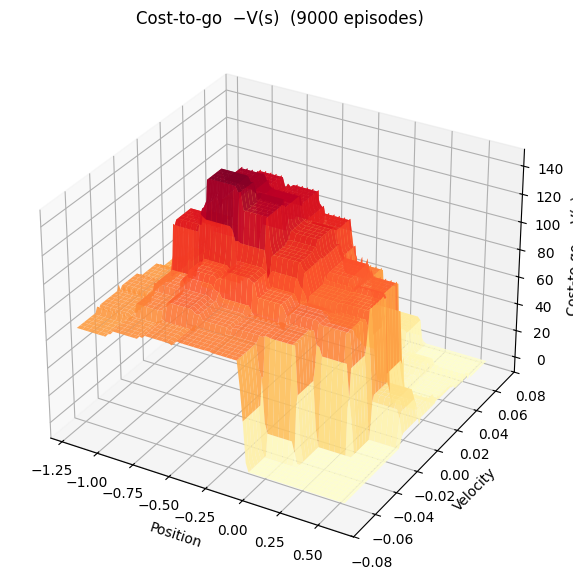

In [ ]:
# ============================================================
# 5. Visualise cost-to-go — 3D surface (Fig 9.10 style)
# ============================================================

n_grid = 80
positions = np.linspace(-1.2, 0.6, n_grid)
velocities = np.linspace(-0.07, 0.07, n_grid)
PV, VV = np.meshgrid(positions, velocities)

# Compute V(s) at each grid point
V = np.zeros((n_grid, n_grid))
for i, p in enumerate(positions):
    for j, v in enumerate(velocities):
        s = np.array([p, v])
        q_vals = [np.dot(tc(s, a_i), w) for a_i in range(3)]
        V[i, j] = np.max(q_vals)
cost_to_go = -V.T  # -V: higher = farther from goal

# --- 3D Surface plot -----------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(PV, VV, cost_to_go, cmap="YlOrRd", edgecolor="none", alpha=0.9)

ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_zlabel("Cost-to-go  −V(s)")
ax.set_title(f"Cost-to-go  −V(s)  ({n_episodes} episodes)")
ax.view_init(elev=30, azim=-60)
plt.show()